In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.preprocessing import LabelEncoder

data_path = "./dynamic_supply_chain_logistics_dataset.csv"
df_ori = pd.read_csv(data_path)

# Convert timestamp column to datetime
df_ori['timestamp'] = pd.to_datetime(df_ori['timestamp'])
df_ori.set_index('timestamp', inplace=True)

# Create risk classification mapping
df = df_ori.copy()
risk_mapping = {'Low Risk': 0, 'Moderate Risk': 1, 'High Risk': 2}
df['risk_classification'] = df_ori['risk_classification'].map(risk_mapping)

In [20]:
mask = (
    df["vehicle_gps_latitude"].between(32.4, 35.8) &
    df["vehicle_gps_longitude"].between(-121.0, -114.0)
)
df = df[mask]

In [7]:
def data_info(data):
    print('1) Number of columns are : ',data.shape[1])
    print('2) Number of rows are : ',data.shape[0])
    print('3) Total number of data-points :',data.size)
    numerical_features = [f for f in data.columns if data[f].dtypes!='O']
    print('4) Count of Numerical Features :',len(numerical_features))
    cat_features = [c for c in data.columns if data[c].dtypes=='O']
    print('5) Count of Categorical Features :',len(cat_features))
data_info(df)

1) Number of columns are :  25
2) Number of rows are :  663
3) Total number of data-points : 16575
4) Count of Numerical Features : 25
5) Count of Categorical Features : 0


In [8]:
def features_with_missing_values(data):
    x = data.isnull().sum().sum()/(data.shape[0]*data.shape[1])*100
    print('Percentage of Total Missing Values is ' ,round(x,2) ,'%')
    print('Missing Value Estimation :')
    for i in data.columns:
        if data[i].isna().sum()>0:
            print('The Feature ',i,' has '+ str(data[i].isna().sum()) + ' missing values')
            
features_with_missing_values(df)

Percentage of Total Missing Values is  0.0 %
Missing Value Estimation :


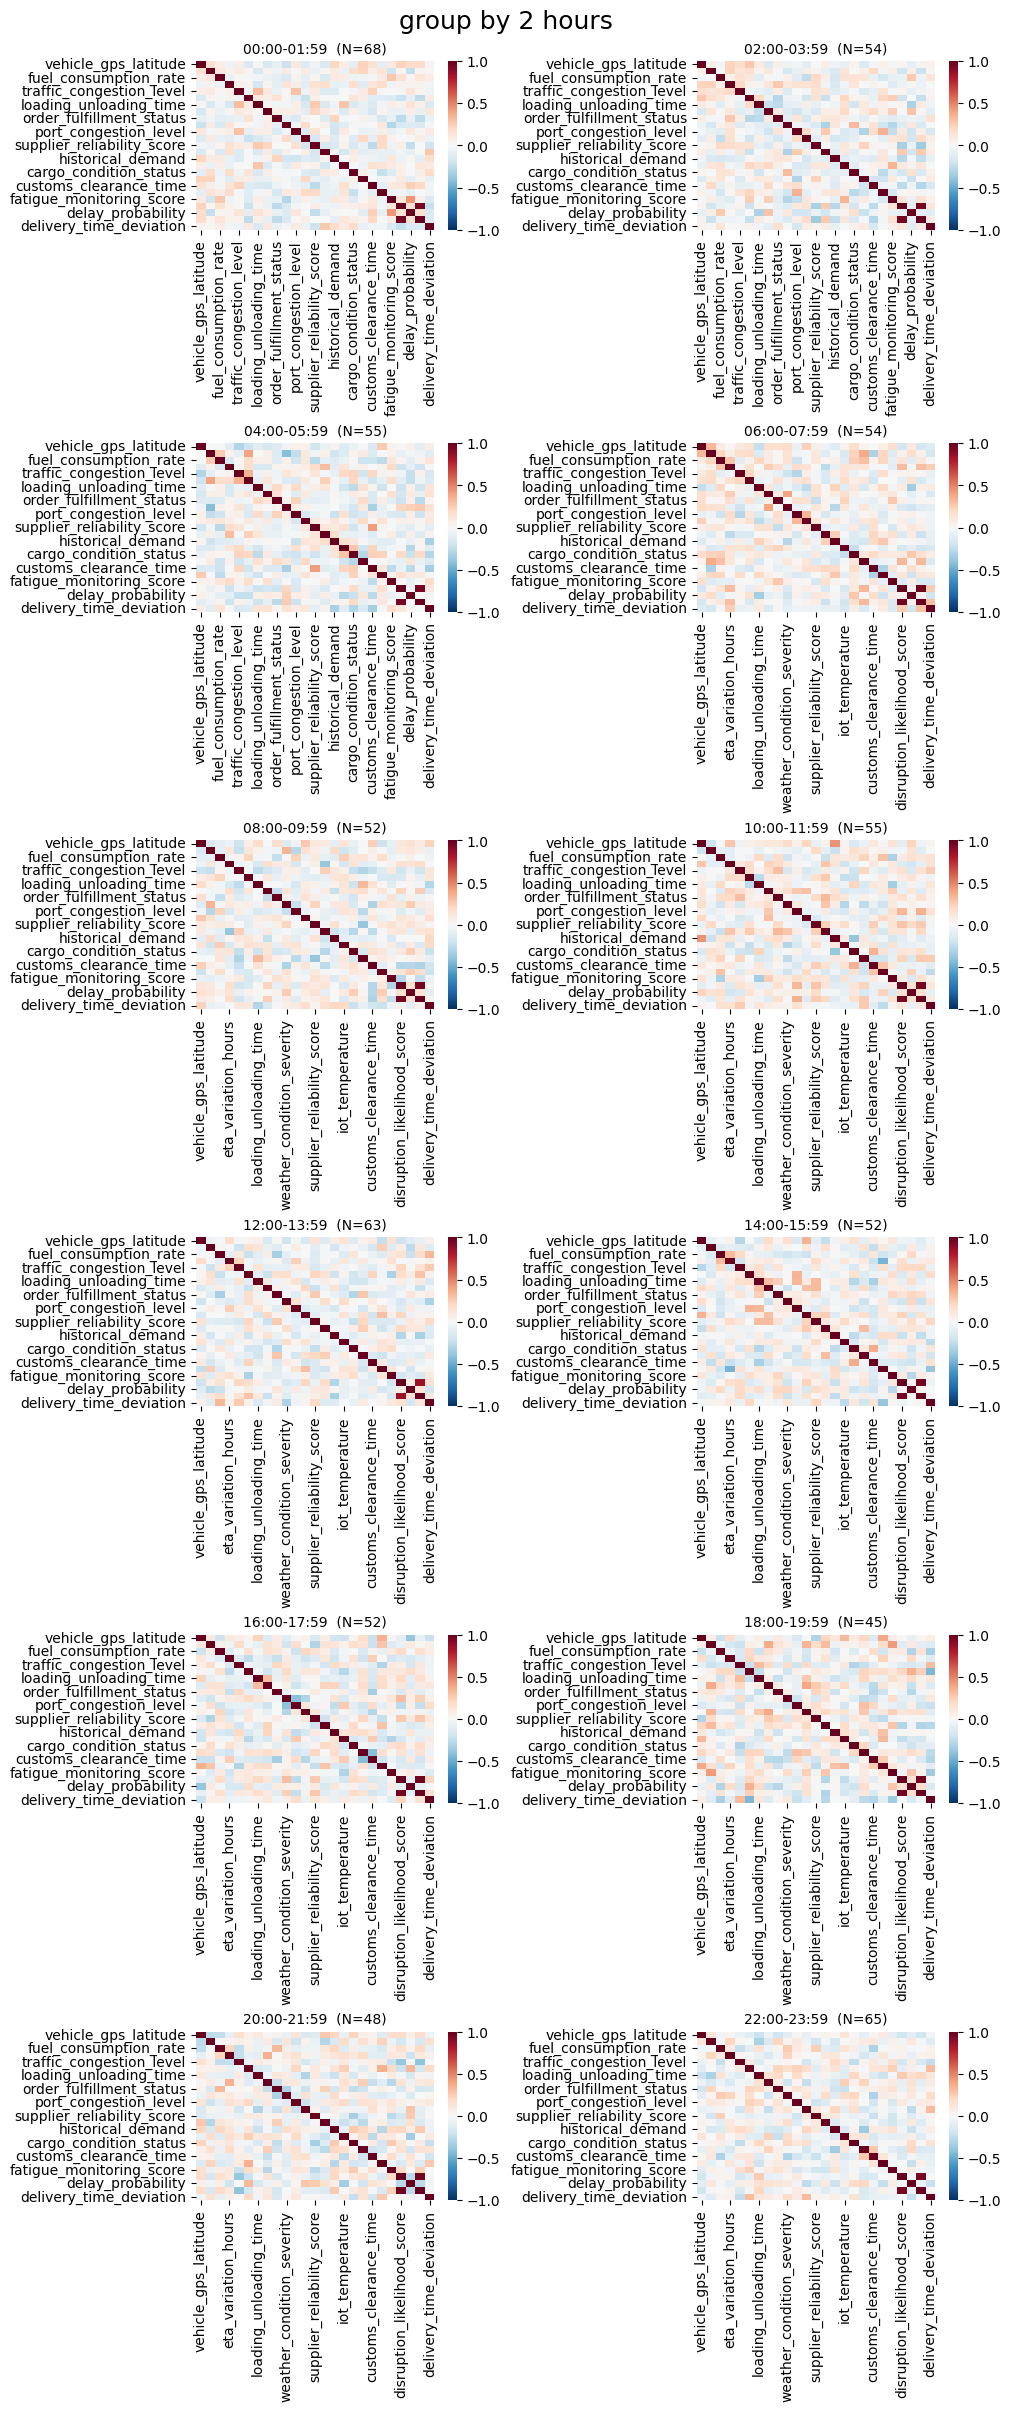

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

if not isinstance(df.index, pd.DatetimeIndex):
    df = df.copy()
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df = df.set_index('timestamp')

hour_bin = df.index.hour // 2

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
fig, axes = plt.subplots(6, 2, figsize=(10, 24), constrained_layout=True)
axes = axes.flatten()

def bin_title(b):
    start_h = int(b) * 2
    end_h = start_h + 1
    return f"{start_h:02d}:00-{end_h:02d}:59"

for b in range(12):
    ax = axes[b]
    grp = df[hour_bin == b]
    use_cols = [c for c in numeric_cols if c in grp.columns]
    corr = grp[use_cols].corr(numeric_only=True)
    sns.heatmap(
        corr,
        vmin=-1, vmax=1, center=0,
        cmap='RdBu_r', annot=False,
        cbar=True, ax=ax
    )
    ax.set_title(f"{bin_title(b)}  (N={len(grp)})", fontsize=10)
    ax.set_xlabel('')
    ax.set_ylabel('')

for k in range(12, len(axes)):
    axes[k].axis('off')

plt.suptitle('group by 2 hours', fontsize=18)
plt.show()


## correlation analysis

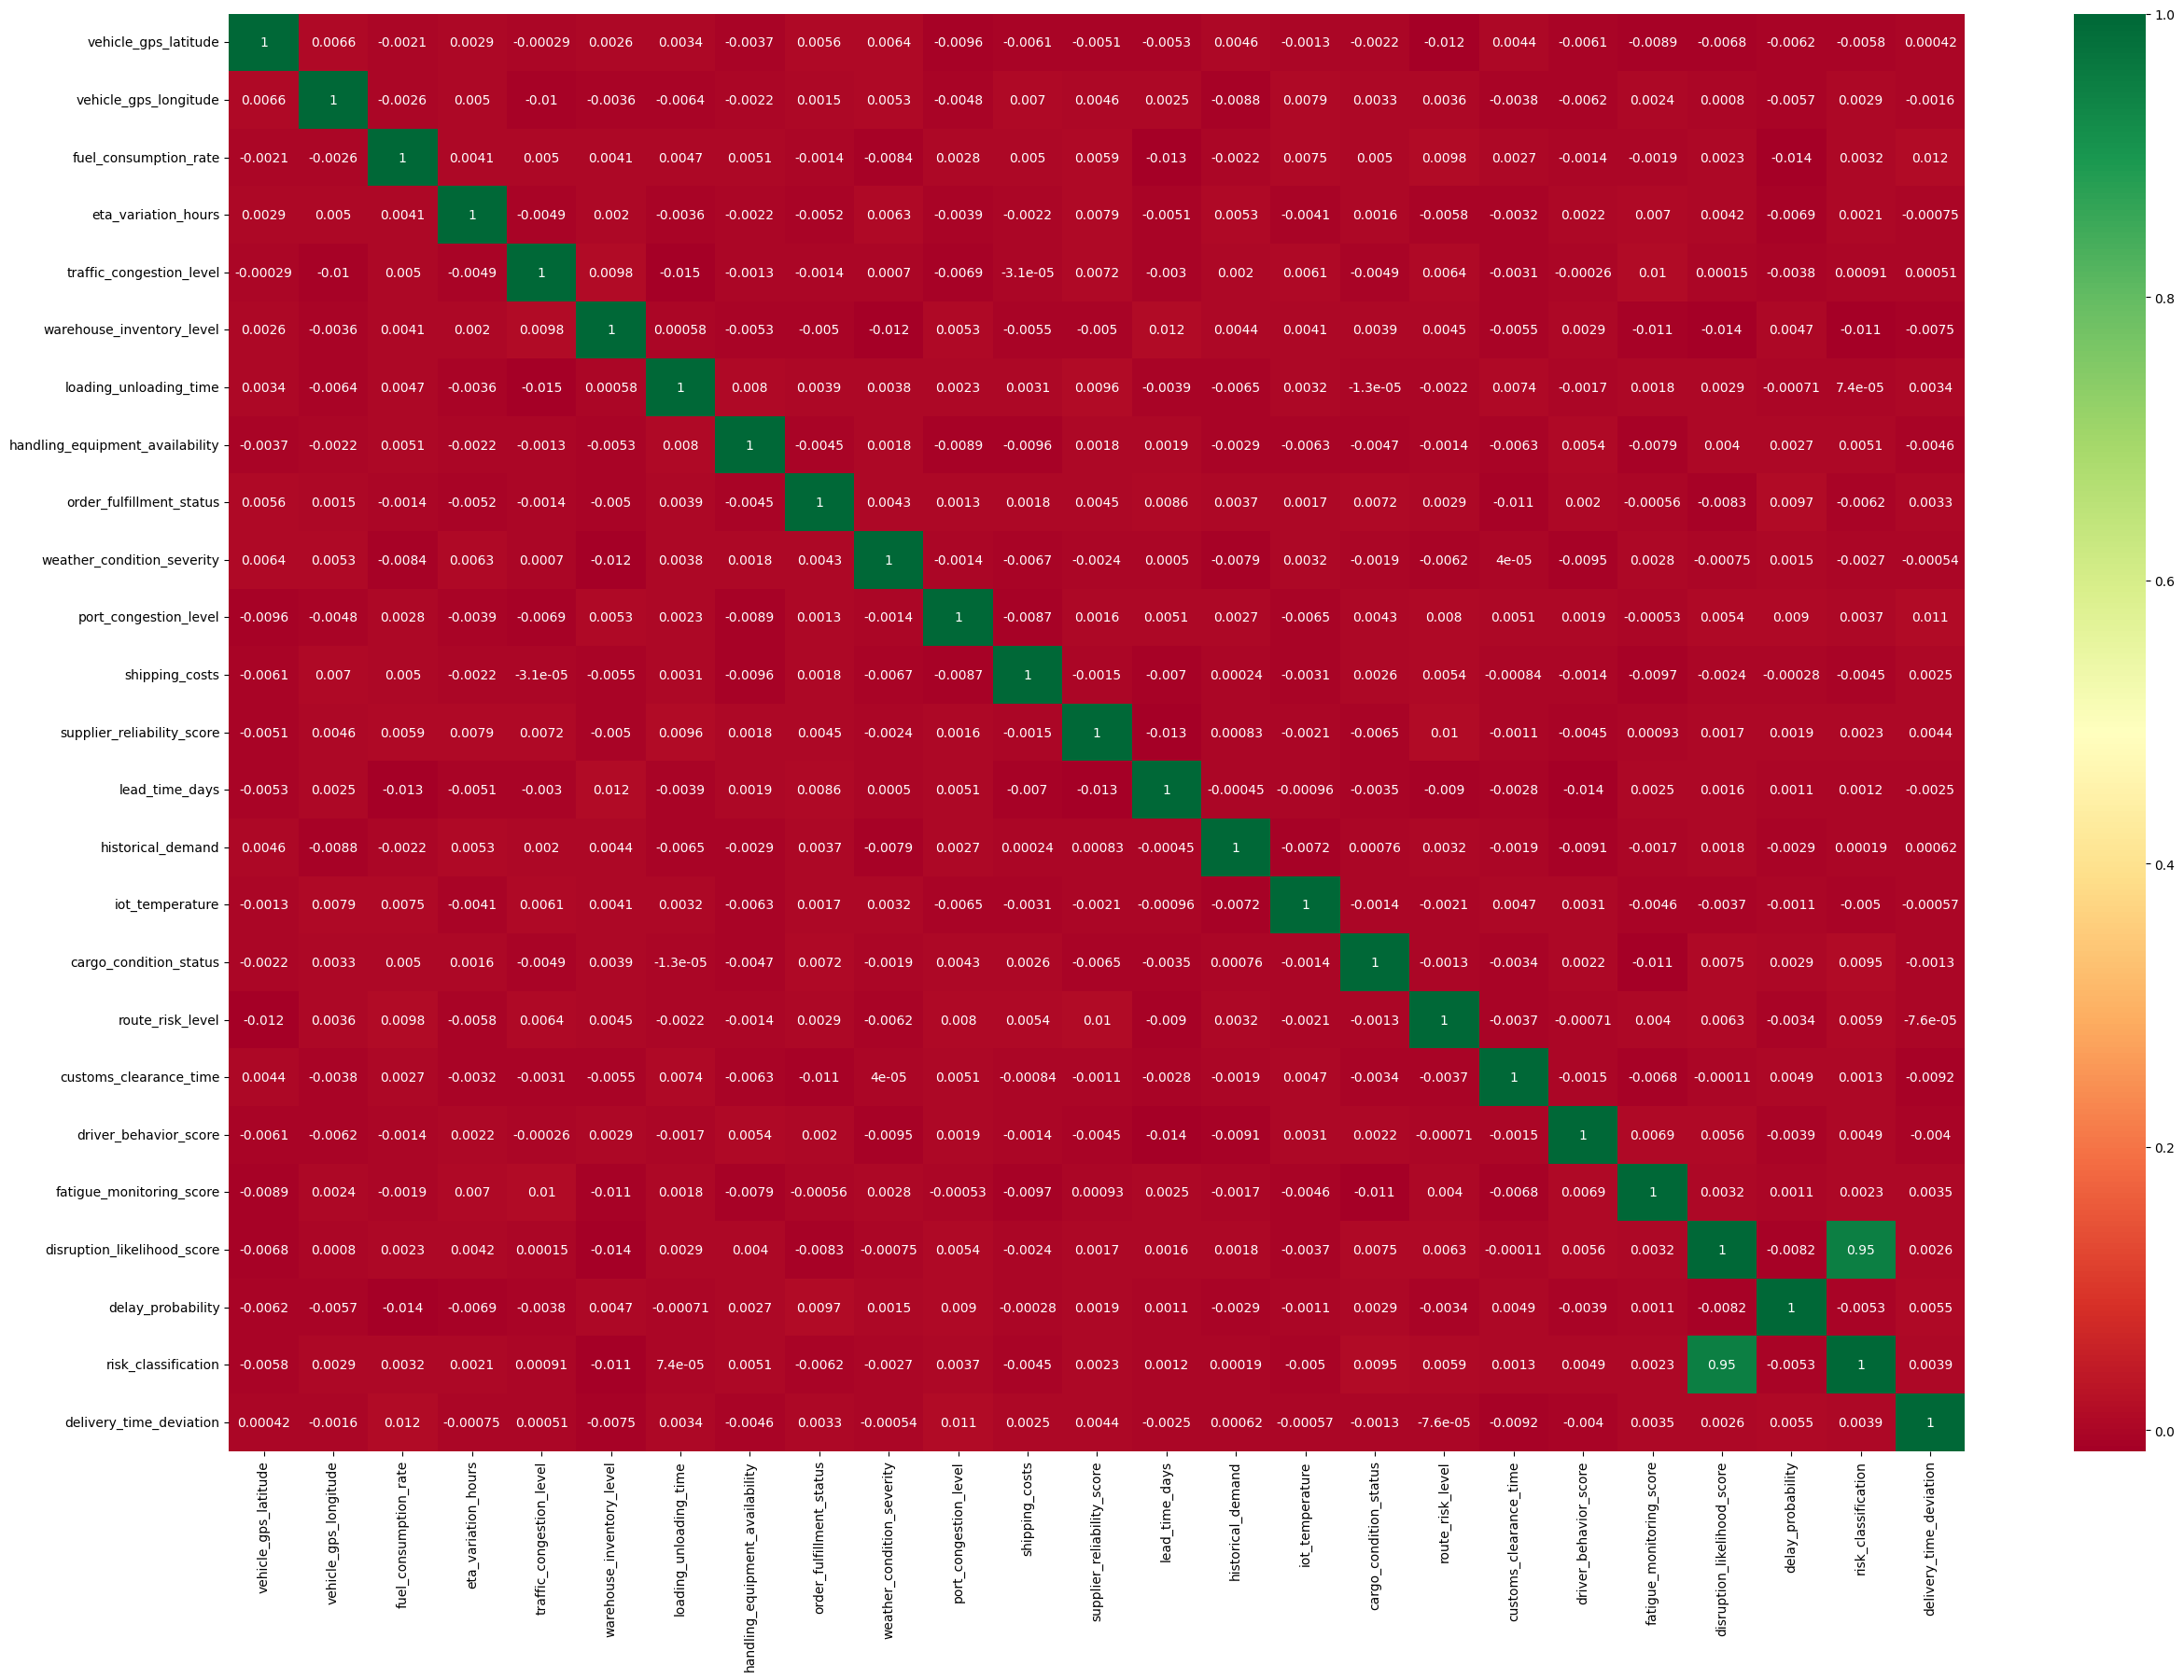

In [ ]:
corrmap = df.corr()
top=corrmap.index
plt.figure(figsize=(30,20))
g=sns.heatmap(df[top].corr(),annot=True,cmap="RdYlGn")